In [ ]:
"""
add notagen corpus
"""
from music21 import *
notagen_corpus = corpus.corpora.LocalCorpus("NOTAGEN")
notagen_corpus.addPath(r"~/Desktop/Repositories/bachAndNotagenCorpora/Baroque_BachJohannSebastian_Choral")
notagen_corpus.save()
for path in notagen_corpus.getPaths():
    score = corpus.parse(path)

"""
import libraries
"""
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import music21 as m21

In [ ]:
"""
1. Keys:
Algorithms: determine key of chorale by applying music21's key finding algorithm.
- count how often each key occurs, e.g.
bach_keys = { "C": 23, "C#": 1. "D": 12, ..."c": 32, "c#": 2, ...}
notagen_keys = { "C": 58, "C#": 1. "D": 6, ..."c": 14, "c#": 2, ...}

2. Time signatures:
Algorithm: take first time signature
bach_tss = { "4/4": 23, "3/4": 1. "5/8": 0, ...}
notagen_tss = { "4/4": 58, "3/4": 1. "5/8": 1, ...}

3. Melodies:
Algorithm:
  - transpose everything to C major / a minor (Bach AND Notagen)
  - take only 10 first notes of Soprano

4. Dominant seventh chords
...

5. Parallel Fiths (Google search)

6. Dv / Neapolitaner
...

7. Auftakte / Volltakte
"""

In [3]:
"""
1. Keys:
Count how often each key occurs for bach and notagen
"""
import music21 as m21
from collections import Counter
keys_BACH = []
keys_notagen = []

# BACHkeys
bach_chorales = m21.corpus.chorales.Iterator()
for c in bach_chorales:
    chorales_key = c.analyze("key")
    keys_BACH.append(f"{chorales_key.tonic.name} {chorales_key.mode}")
keys_total = Counter(keys_BACH)
bach_keys = keys_total

# NOTAGENkeys
for path in notagen_corpus.getPaths():
    score = m21.corpus.parse(path)
    ai_keys = score.analyze("key")
    keys_notagen.append(f"{ai_keys.tonic.name} {ai_keys.mode}")
ai_keys = Counter(keys_notagen)


# convert Counter to pandas DataFrame
df_keys = (
    pd.DataFrame({
        "Bach": bach_keys,
        "Notagen": ai_keys
    })
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": "key_name"})
)

df_keys # convert to df 1 column feature (key) 2nd column count bach, 3rd column
df_keys["key_name"] = df_keys["key_name"].str.replace("-", "b")


In [5]:
df_keys

,key_name,Bach,Notagen
0,G major,52,19
1,A major,32,3
2,A minor,45,6
3,E major,8,0
4,F major,24,7
5,F minor,2,1
6,C major,17,4
7,D major,25,6
8,D minor,26,4
9,B minor,28,22


In [ ]:
# ADD KEY PLOT
COLORS = ["#9a5ea1", "#98823c"]  # colorblind-friendly

def plot_diverging_bars(df, save: str=None, colors=COLORS):
  df = df.sort_values(by="Bach")

  _, axes = plt.subplots(1, 2, sharey=True)
  axes[0].barh(df.iloc[:, 0], df["Bach"], label="Bach", color=colors[0], align="center")
  axes[0].set_title(f"Bach (n={df["Bach"].sum()})")
  axes[0].invert_xaxis()
  axes[0].yaxis.tick_right()

  axes[1].barh(df.iloc[:, 0], df["Notagen"], label="Notagen", color=colors[1])
  axes[1].set_title(f"Notagen (n={df["Notagen"].sum()})")
  # axes[1].set_xlim(0, max_val * 1.1)  ## only uncomment if we have the same number of Notagen pieces as Bach

  for i, ax in enumerate(axes):
    xlim = max([p.get_width() for p in ax.patches]) * 1.2
    for rect in ax.patches:
      x = rect.get_width()
      y = rect.get_y() + rect.get_height() / 2
      offset = -1 if i == 0 else 1
      ax.annotate(
          x,
          (x, y),
          ha="right" if i == 0 else "left",
          va="center",
          color="black",
          fontsize=12,
          xytext=(offset * 5, 0),
          textcoords="offset points",
      )
    factor = 1.35
    if i == 0:
      ax.set_xlim(xlim, 0)
    else:
      ax.set_xlim(0, xlim)

  plt.subplots_adjust(wspace=.2)
  plt.tight_layout()
  if save:
    plt.savefig(save)
  plt.show()


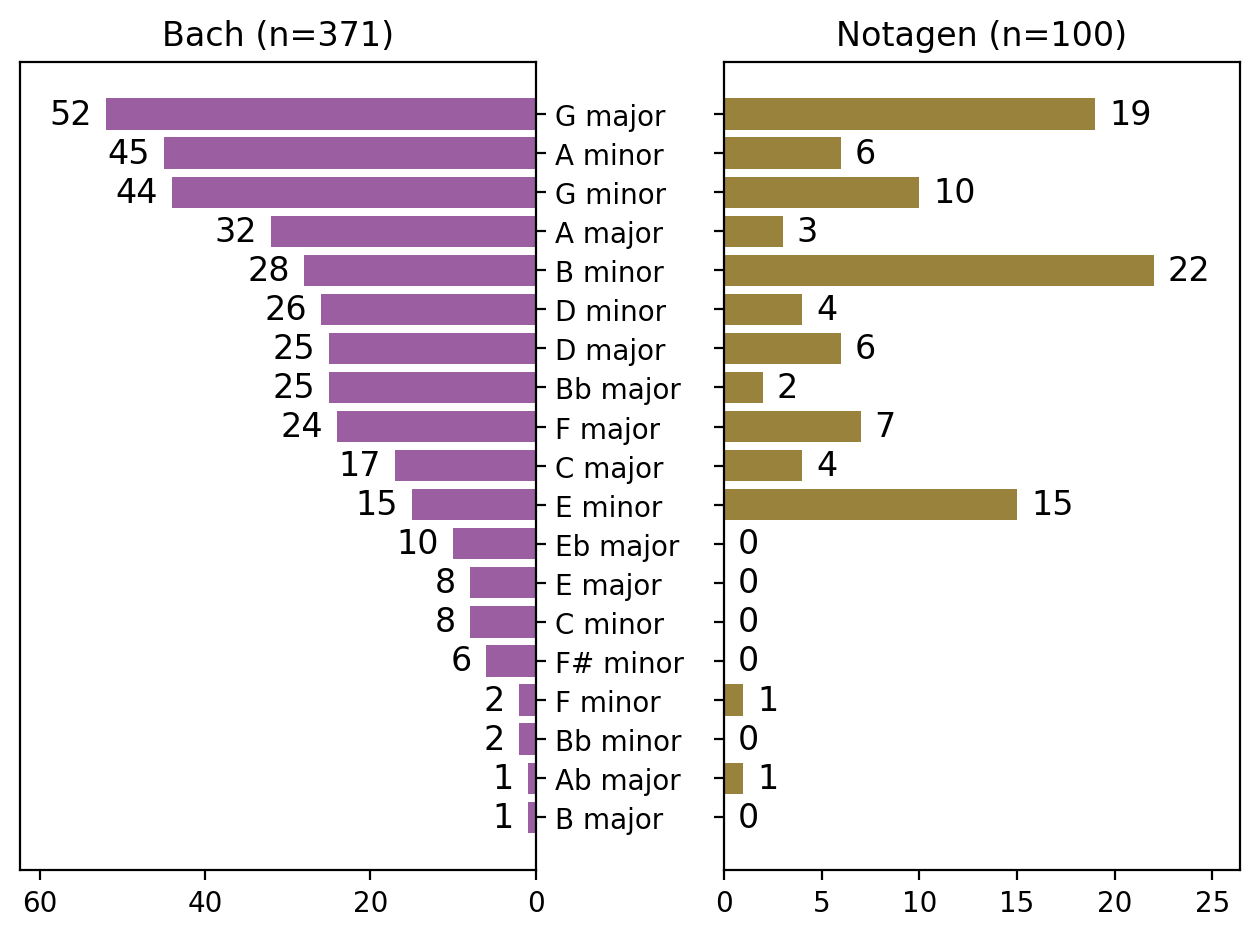

In [8]:
plot_diverging_bars(df_keys, save="key_comparison.pdf")

In [7]:
"""
2. Time signatures:
"""
from collections import Counter

# BACH

bach_tss_list = []
bach_chorales = m21.corpus.chorales.Iterator()
for piece in bach_chorales:
    time_sig = piece.recurse().getElementsByClass(m21.meter.TimeSignature)[0]
    bach_tss_list.append(time_sig.ratioString)
bach_tss = Counter(bach_tss_list)

# NOTAGEN
notagen_tss_list = []
for path in notagen_corpus.getPaths():
    score = m21.corpus.parse(path)
    time_sig = score.recurse().getElementsByClass(m21.meter.TimeSignature)[0]
    notagen_tss_list.append(time_sig.ratioString)
notagen_tss = Counter(notagen_tss_list)

# convert Counter to df

df_tss = (
    pd.DataFrame({
        "Bach": bach_tss,
        "Notagen": notagen_tss
    })
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": "tss"})
)
df_tss

,tss,Bach,Notagen
0,3/4,38,0
1,4/4,331,100
2,3/2,1,0
3,12/8,1,0


A few Bach pieces have multiple Time Signatures (see cell below)

In [3]:
from collections import Counter
bach_tss_list = []
bach_chorales = m21.corpus.chorales.Iterator()
for piece in bach_chorales:
    time_sig = piece.recurse().getElementsByClass(m21.meter.TimeSignature)[1]
    bach_tss_list.append(time_sig.ratioString)
bach_tss = Counter(bach_tss_list)
df_tss = (
    pd.DataFrame({
        "Bach": bach_tss
    })
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": "tss"})
)
df_tss

,tss,Bach
0,3/4,41
1,4/4,327
2,3/2,2
3,12/8,1


In [ ]:
"""
3. Melodies:
Algorithm:
  - transpose everything to C major / a minor (Bach AND Notagen)
  - take only 10 first notes of Soprano
"""
import music21 as m21
count = 0
def extract_snippets(corpus=None):
  if corpus is not None:
    snippets = {}
    rem_snippets = []
    for chorale in corpus:
      try:
        ## transpose to C
        key = chorale.analyze("key")
        if key.mode == "major":
          interval = m21.interval.Interval(key.tonic, m21.pitch.Pitch("C"))
        elif key.mode == "minor":
          interval = m21.interval.Interval(key.tonic, m21.pitch.Pitch("A"))
        else:
          print("error")

        transposed = chorale.transpose(interval)
        for part in chorale.parts:
          if part.partName == "Soprano": # does that work? We should do smell-tests
            id = transposed.metadata.movementName
            soprano = transposed.recurse().notes # <--- we needed recurse instead of flatten! i dont know why, but with flatten the transposed snippets were not right
            # notes = [note.pitch.nameWithOctave for note in soprano.notes][:10]
            notes = [note.pitch.midi for note in soprano.notes][:10]
            snippets[id] = notes
          else:
            print(part.partName) # rem_snippets[id]
      except:
        # print("except", chorale)
        pass

    return snippets
  else:
    return None

bach_chorales = m21.corpus.chorales.Iterator()
bach_snippets = extract_snippets(corpus=bach_chorales)
bach_snippets

In [4]:
def extract_notagen_snippets(corpus=None):
  if corpus is not None:
    snippets = {}
    for chorale in corpus.getPaths():
      chorale = m21.corpus.parse(chorale)
      try:
        ## transpose to C
        key = chorale.analyze("key")
        if key.mode == "major":
          interval = m21.interval.Interval(key.tonic, m21.pitch.Pitch("C"))
        elif key.mode == "minor":
          interval = m21.interval.Interval(key.tonic, m21.pitch.Pitch("A"))
        else:
          print("error")

        transposed = chorale.transpose(interval)
        women_parts = transposed.recurse().getElementsByClass(m21.stream.Part)["Women"] # filter out the men-parts
        soprano = stream.Part() # add a new soprano part
        for v in women_parts.recurse().getElementsByClass(m21.stream.Voice): #filter the Women-Parts by Voices
          if v.id == "1": # Voice 1 is the Soprano we want to extract.
            for n in v.recurse().notes: # appending the notes of Voice 1 to our new Soprano Part
              soprano.append(n)

        notes = [note.pitch.midi for note in soprano.notes]
        snippets[transposed.metadata.movementName] = notes[:10]

      except:
        print("except", chorale)
        pass
    return snippets
notagen_snippets = extract_notagen_snippets(notagen_corpus)
notagen_snippets

{'output1.xml': [72, 72, 71, 69, 67, 72, 72, 71, 72, 72],
 'output10.xml': [64, 65, 67, 67, 65, 64, 62, 62, 64, 66],
 'output100.xml': [64, 67, 65, 64, 62, 64, 66, 67, 67, 64],
 'output11.xml': [69, 69, 71, 72, 71, 76, 74, 72, 71, 72],
 'output12.xml': [69, 69, 71, 72, 71, 76, 74, 72, 71, 72],
 'output13.xml': [76, 76, 74, 72, 71, 69, 76, 78, 79, 76],
 'output14.xml': [64, 60, 62, 64, 65, 67, 67, 69, 67, 65],
 'output15.xml': [76, 76, 81, 80, 81, 76, 74, 76, 77, 76],
 'output16.xml': [76, 76, 74, 72, 71, 76, 74, 72, 71, 72],
 'output17.xml': [69, 69, 71, 72, 71, 68, 64, 72, 71, 69],
 'output18.xml': [60, 60, 62, 64, 62, 64, 65, 64, 62, 60],
 'output19.xml': [60, 67, 67, 67, 67, 69, 67, 65, 64, 62],
 'output2.xml': [76, 76, 76, 76, 81, 81, 81, 80, 76, 79],
 'output20.xml': [69, 69, 71, 72, 71, 76, 74, 72, 71, 72],
 'output21.xml': [69, 64, 69, 69, 71, 67, 66, 66, 64, 60],
 'output22.xml': [60, 67, 67, 67, 67, 69, 67, 65, 64, 62],
 'output23.xml': [60, 60, 67, 67, 65, 64, 62, 64, 65, 64]

Total D7-Chord Count (Bach): 2831
Total D7-Chord Count (Notagen): 574


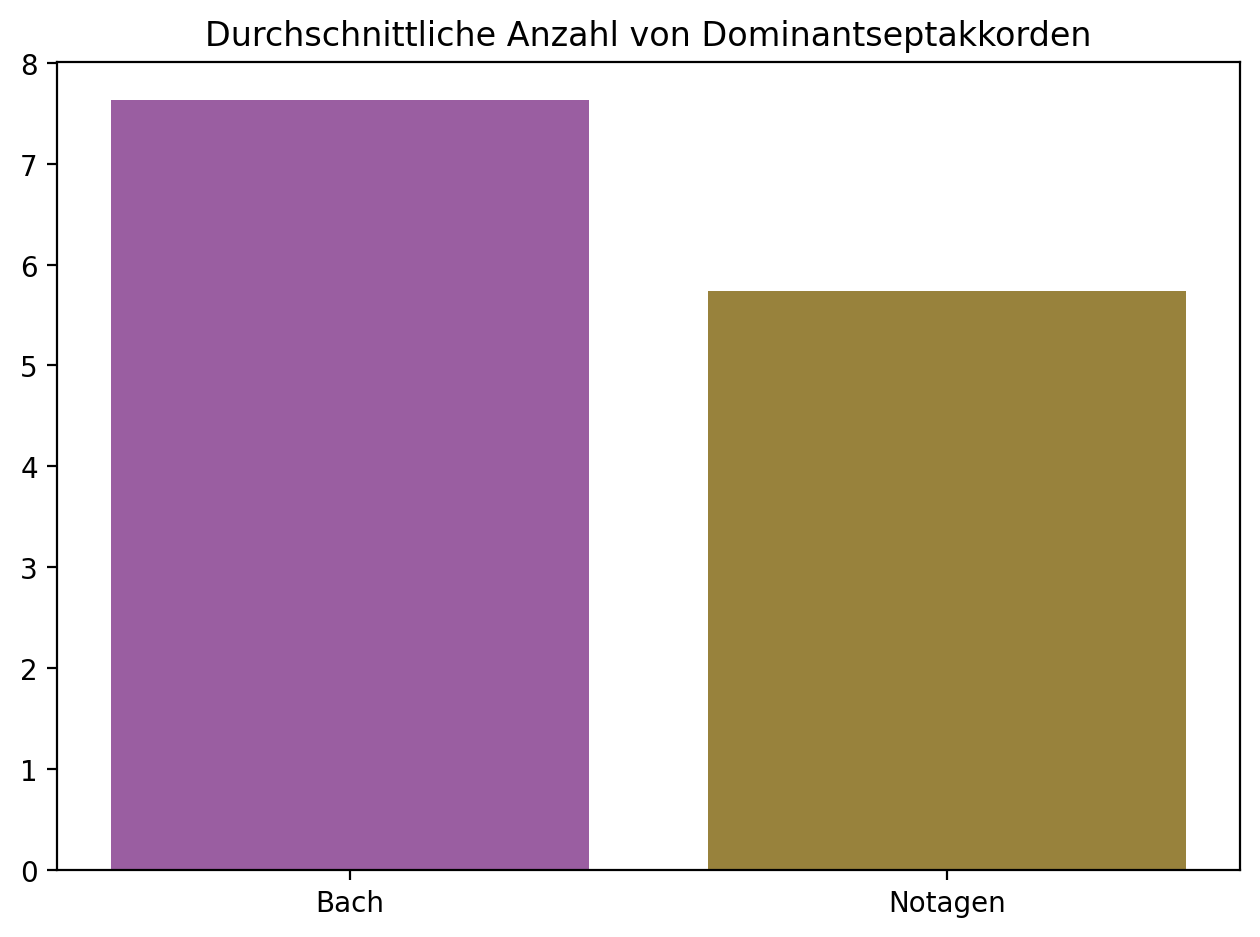

In [18]:
"""
4. Dominant seventh chords
"""
import music21 as m21
import numpy as np
# NOTAGEN

d7_count_ai = 0
d7_ai_chord_list = [] #do we want/need a list? maybe we could specify what d7 chords occur often?
for path in notagen_corpus.getPaths():
    score = corpus.parse(path)
    scoreChords = score.chordify()
    for chord in scoreChords.recurse().getElementsByClass(m21.chord.Chord):
        if chord.isDominantSeventh():
            d7_ai_chord_list.append([chord.beatStr, chord])
            d7_count_ai += 1
        else:
            continue


# BACH
d7_count = 0
d7_bach_chord_list = []

bach_chorales = m21.corpus.chorales.Iterator()
for piece in bach_chorales:
    pieceChords = piece.chordify()
    for chord in pieceChords.recurse().getElementsByClass(m21.chord.Chord):
        if chord.isDominantSeventh():
            d7_bach_chord_list.append([chord.beatStr, chord])
            d7_count += 1
        else:
            continue

print(f"Total D7-Chord Count (Bach): {d7_count}")
print(f"Total D7-Chord Count (Notagen): {d7_count_ai}")
x  = np.array(["Bach", "Notagen"])
y = np.array([d7_count / 371, d7_count_ai / 100]) ## relative counts
plt.bar(x, y, color=COLORS)
plt.title("Durchschnittliche Anzahl von Dominantseptakkorden")
plt.tight_layout()
#plt.savefig("dominant_chords.pdf")
plt.show()

In [21]:
import pandas as pd
df_bach = pd.DataFrame(bach_snippets).T.astype(int)
df_notagen = pd.DataFrame(notagen_snippets).T.astype(int)

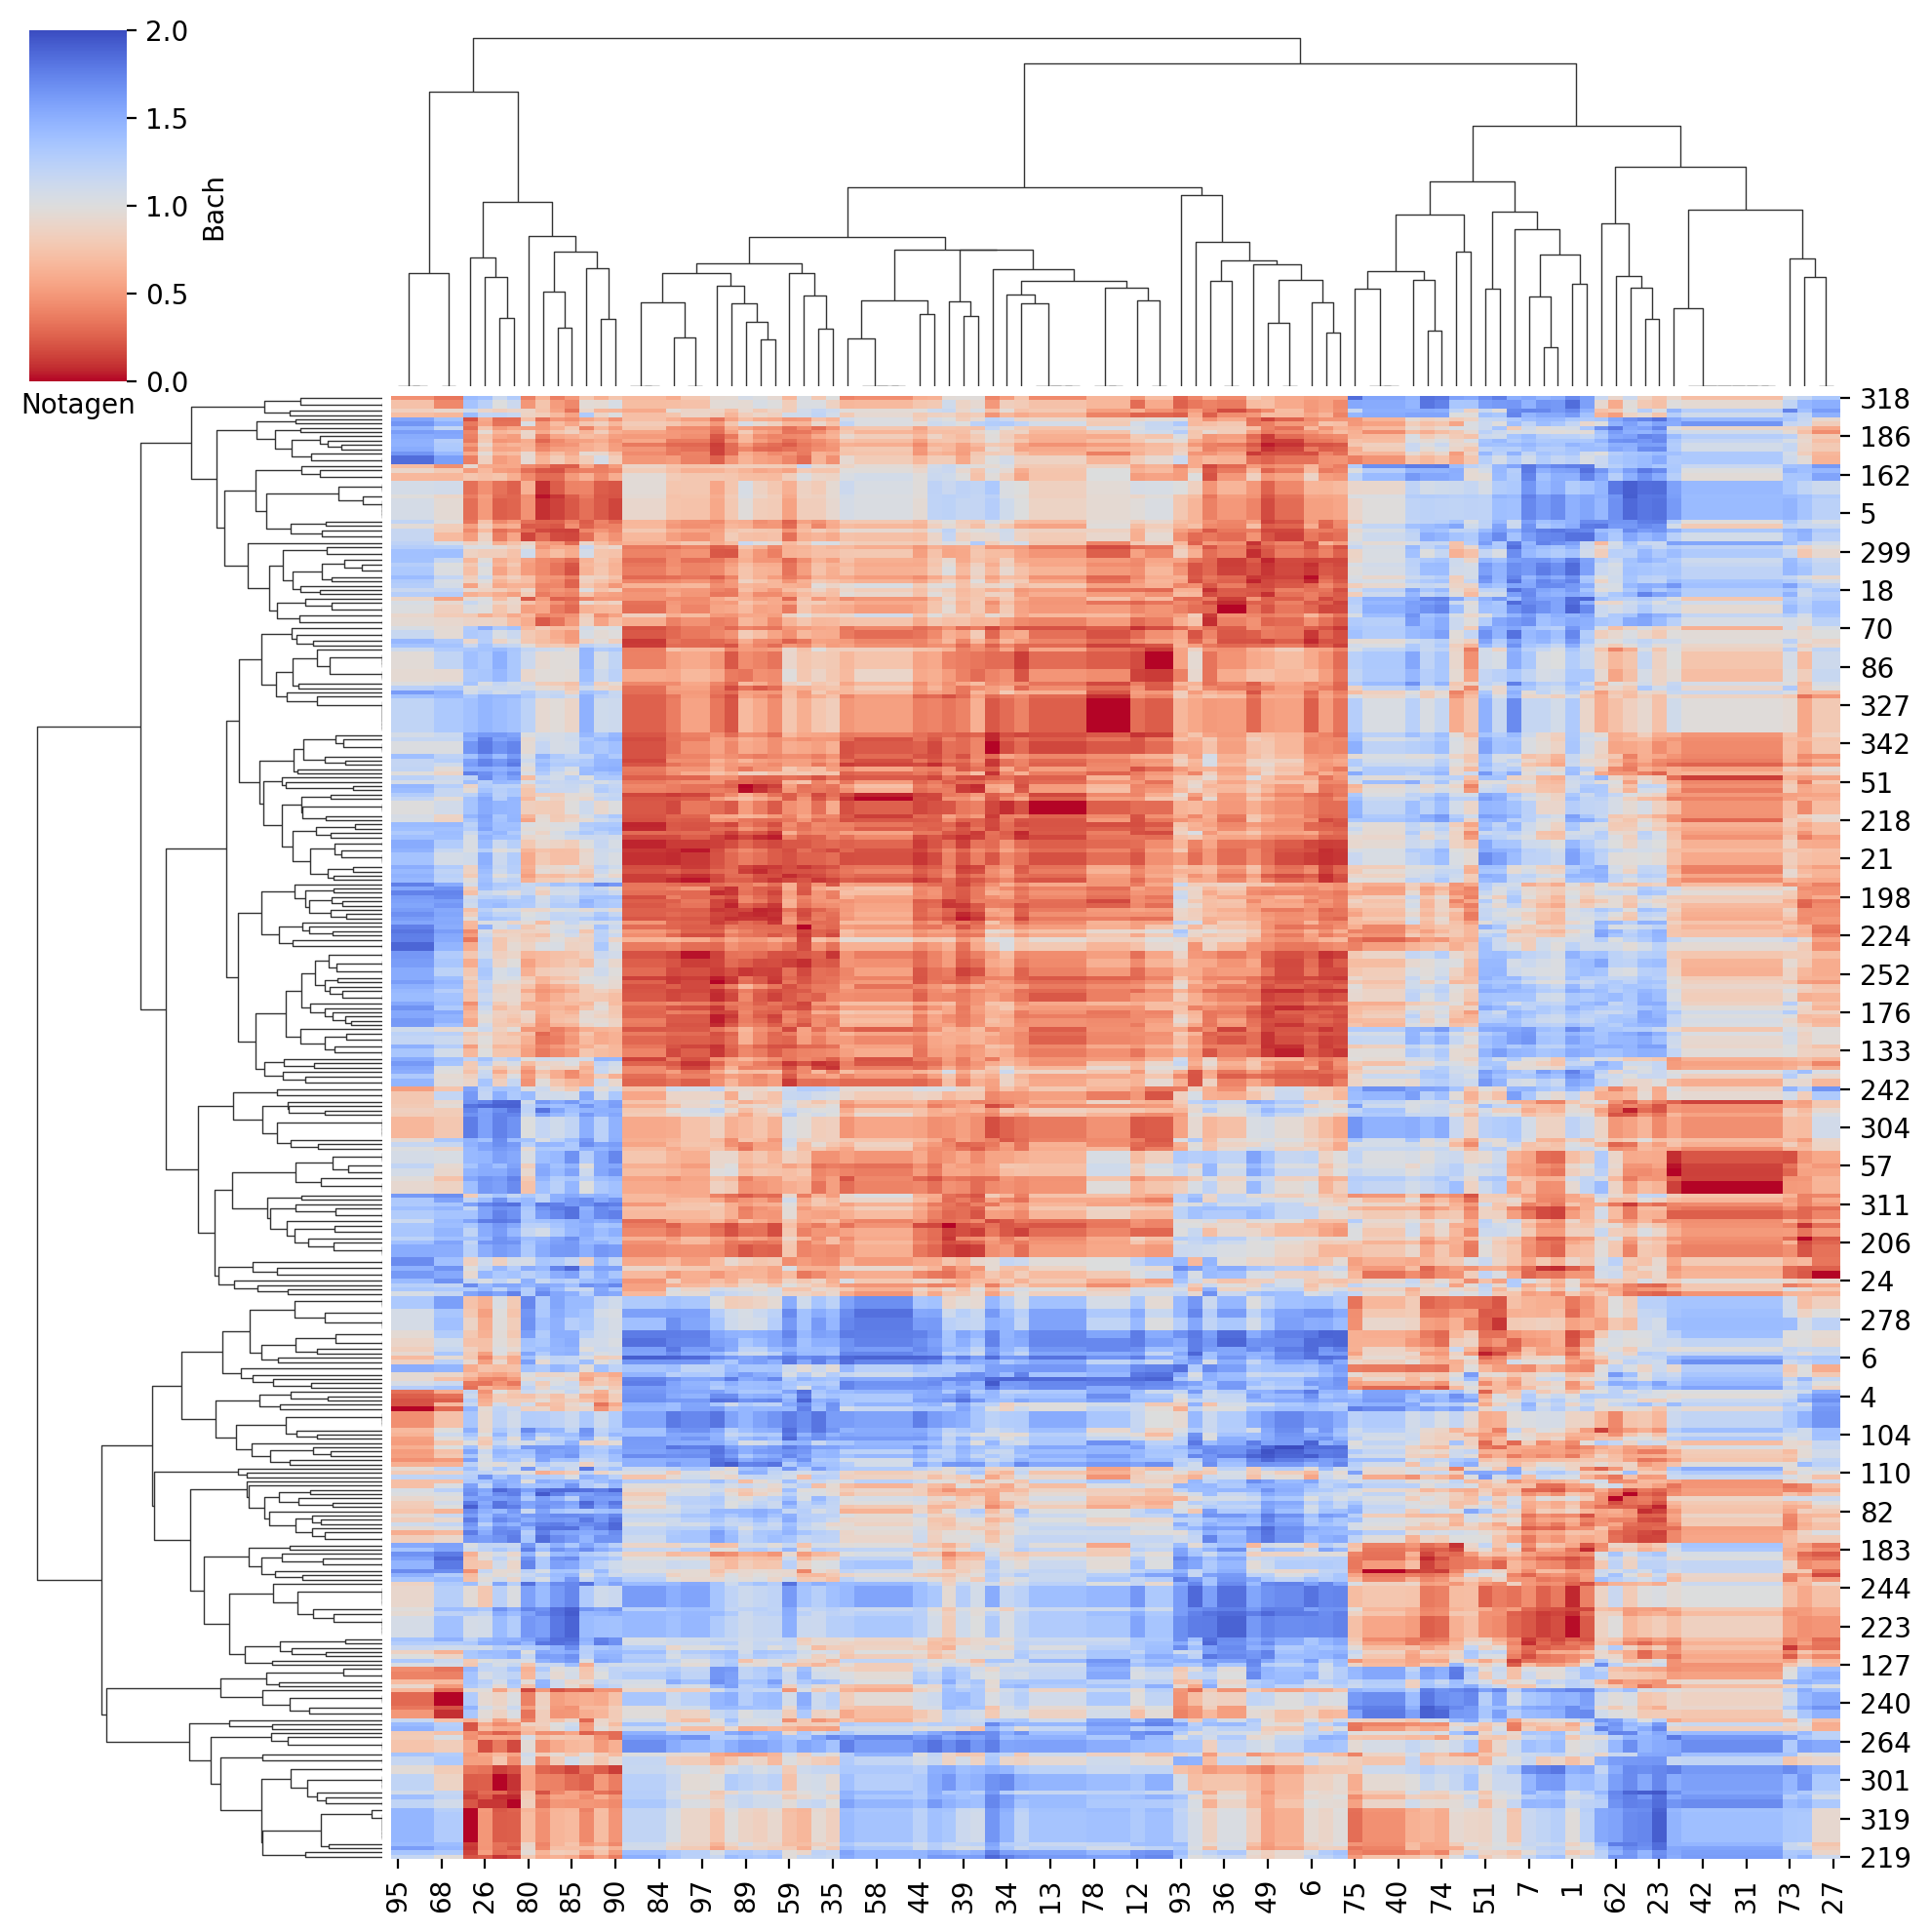

In [27]:
from sklearn.metrics import pairwise_distances
import seaborn as sns

dists = pairwise_distances(df_bach.values, Y=df_notagen.values, metric="correlation")

sns.clustermap(dists, cmap="coolwarm_r")
plt.xlabel("Notagen")
plt.ylabel("Bach")
plt.show()

In [ ]:
# ==================================
# FIND ALL CHORDNAMES IN BACH CORPUS
# ==================================

import music21 as m21
from collections import Counter
chords = []
def chord_names(corpus=None):
    if corpus is not None:
     for chorale in corpus: 
        chorale = chorale.chordify()
        for chord in chorale.recurse().getElementsByClass(m21.chord.Chord): # find all chords
            chords.append(chord.commonName)
    # Put chords into Counter
    counter = Counter(chords)
    # Normalize and round .2
    total = sum(counter.values())
    for key in counter:
        counter[key] = round(counter[key] / total, 2)
    return counter

chord_names(m21.corpus.chorales.Iterator())

Counter({'major triad': 0.35,
         'minor triad': 0.17,
         'dominant seventh chord': 0.09,
         'minor seventh chord': 0.05,
         'diminished triad': 0.04,
         'quartal trichord': 0.04,
         'major seventh chord': 0.03,
         'major-second major tetrachord': 0.02,
         'incomplete minor-seventh chord': 0.02,
         'incomplete dominant-seventh chord': 0.02,
         'major-second minor tetrachord': 0.02,
         'quartal tetramirror': 0.02,
         'half-diminished seventh chord': 0.02,
         'perfect-fourth major tetrachord': 0.01,
         'Major Third with octave doublings': 0.01,
         'incomplete major-seventh chord': 0.01,
         'Minor Third with octave doublings': 0.01,
         'perfect-fourth minor tetrachord': 0.01,
         'diminished seventh chord': 0.01,
         'minor tetramirror': 0.0,
         'perfect-fourth diminished tetrachord': 0.0,
         'incomplete half-diminished seventh chord': 0.0,
         'all-interval tetr

In [9]:
# =====================================
# FIND ALL CHORDNAMES IN NOTAGEN CORPUS
# =====================================

import music21 as m21
from collections import Counter
chords_notagen = []

def notagen_chord_names(corpus=None):
    if corpus is not None:
        for path in corpus.getPaths():
            chorale = m21.corpus.parse(path)   
            chorale = chorale.chordify()
            for chord in chorale.recurse().getElementsByClass(m21.chord.Chord):
                chords_notagen.append(chord.commonName)
        # Insert into Counter
        counter = Counter(chords_notagen)
        # Normalize and round .2
        total = sum(counter.values())
        for key in counter:
            counter[key] = round(counter[key] / total, 2)
    return counter

notagen_chord_names(notagen_corpus)    

Counter({'major triad': 0.31,
         'minor triad': 0.17,
         'dominant seventh chord': 0.08,
         'minor seventh chord': 0.06,
         'quartal trichord': 0.04,
         'diminished triad': 0.04,
         'major seventh chord': 0.03,
         'half-diminished seventh chord': 0.03,
         'incomplete dominant-seventh chord': 0.03,
         'major-second major tetrachord': 0.02,
         'quartal tetramirror': 0.02,
         'incomplete minor-seventh chord': 0.02,
         'perfect-fourth minor tetrachord': 0.01,
         'Perfect Fifth with octave doublings': 0.01,
         'incomplete major-seventh chord': 0.01,
         'Major Third with octave doublings': 0.01,
         'perfect-fourth major tetrachord': 0.01,
         'major-second minor tetrachord': 0.01,
         'Minor Third with octave doublings': 0.01,
         'diminished seventh chord': 0.01,
         'all-interval tetrachord': 0.01,
         'minor-second diminished tetrachord': 0.0,
         'tritone-fourth':

# The Chord-Proportions look quite similar!

In [8]:
# ================================================================
# OCCURANCE OF DESCENDING AND ASCENDING NOTES IN THE BACH CHORALES
# ================================================================
prev_note = None
asc_count = 0
desc_count = 0
for chorale in corpus.chorales.Iterator():
    for n in chorale.recurse().getElementsByClass(note.Note):
        if prev_note is not None:
            if n.pitch.midi > prev_note.pitch.midi:
                asc_count += 1
            elif n.pitch.midi < prev_note.pitch.midi:
                desc_count += 1
        prev_note = n

print(f"Ascending Notes: {asc_count} Descending Notes: {desc_count:}")

print(f"Relative proportion (Ascending - Descending): {(asc_count / desc_count):.2f}")

Ascending Notes: 36611 Descending Notes: 40963
Relative proportion (Ascending - Descending): 0.89


In [7]:
# ===================================================================
# OCCURANCE OF DESCENDING AND ASCENDING NOTES IN THE NOTAGEN CHORALES
# ===================================================================

prev_note = None
asc_count = 0
desc_count = 0

for path in notagen_corpus.getPaths():
    chorale = corpus.parse(path)
    for n in chorale.recurse().getElementsByClass(note.Note):
        if prev_note is not None:
            if n.pitch.midi > prev_note.pitch.midi:
                asc_count += 1
            elif n.pitch.midi < prev_note.pitch.midi:
                desc_count += 1
        prev_note = n
print(f"Ascending Notes: {asc_count} Descending Notes: {desc_count:}")

print(f"Relative proportion (Ascending - Descending): {(asc_count / desc_count):.2f}")

Ascending Notes: 8249 Descending Notes: 9739
Relative proportion (Ascending - Descending): 0.85


In [ ]:
# ==============================================================
# EXTRACT THE PERCENTAGE OF SHARP/FLAT NOTES WITHIN THE CHORALES
# ==============================================================
"""
Careful! Apparently a few key-analyses of the algorithm are not accurate (e.g. see bwv153.1)
=> Percentages do not vary a lot!
"""
def all_note_count(corpus):
    all_notes = []
    natural_count = 0
    flat_count = 0
    sharp_count = 0
    for chorale in corpus:
        piece_key = chorale.analyze("key")
        for notes in chorale.recurse().getElementsByClass(note.Note):
            all_notes.append(notes)
            if notes.pitch.accidental is None:
                natural_count += 1
            elif notes.pitch.accidental == pitch.Accidental("sharp"):
                sharp_count += 1
            elif notes.pitch.accidental == pitch.Accidental("flat"):
                flat_count += 1
        print(f"{chorale.id}: \n SHARP PERCENTAGE: {(sharp_count / len(all_notes)):.5f} \n FLAT PERCENTAGE: {(flat_count / len(all_notes)):.5f} \n Key: {piece_key}")                           
all_note_count(corpus=corpus.chorales.Iterator())

In [ ]:
"""
5. Check for parallel fifths (TODO)
"""


def parallel_fifths(corpus=None):
    if corpus is not None:
        for chorales in corpus:
            parts = chorales.parts
            if len(parts) == 4:
                notes_by_part = [part.recurse().notes for part in parts]
                
                # Check each pair of parts

                for i in range(len(notes_by_part)):
                    for j in range(i + 1, len(notes_by_part)):
                        v1, v2 = notes_by_part[i], notes_by_part[j]

parallel_fifths(corpus.chorales.Iterator())

In [ ]:
"""
Phrase starting on upbeat / downbeats
"""

In [ ]:
# =============================================
# COUNT MEASURES + NOTES FOR EVERY PIECE (BACH)
# =============================================


# total_notes = 0
# total_notes_list = []
# total_measures = 0
# for i in range(1, 101):
#   ai_piece = m21.converter.parse(f"{DATA}/output{i}.xml")
#   ai_piece_notes = len(ai_piece.recurse().notes)
  
#   ai_piece_measures = sopr.getElementsByClass("Measure")
#   total_notes += ai_piece_notes
#   total_notes_list.append(ai_piece_notes)
#   total_measures += len(ai_piece_measures)
#   print(f" Total Notes for Piece {i}: {ai_piece_notes}, Number of Measures: {len(ai_piece_measures)}", end="")
#   print("")
# print(f"Average Notes per piece: {total_notes / 100:.2f}")
# print(f"Average Measures per piece: {total_measures / 100:.2f}")

# variance = np.var(total_notes_list)
# stand_dev = np.sqrt(variance)

# print(f"Die Standardabweichung beträgt {stand_dev:.2f}")

def measure_note_count():
  total_notes = 0
  total_notes_list = []
  total_measures = 0
  for path in notagen_corpus.getPaths():

    # ITERATION

    piece = corpus.parse(path)
    sopr = piece.parts[0]
    piece_measures = sopr.getElementsByClass("Measure")
    piece_notes = len(piece.recurse().notes)

    # COUNTING OPERATIONS

    total_notes += piece_notes
    total_notes_list.append(piece_notes)
    total_measures += len(piece_measures)

    # PRINT (uncomment when you want to see all iterations)

    # print(f" Total Notes for Piece {piece.metadata.movementName}: {piece_notes}, Number of Measures: {len(piece_measures)}", end="\n")
    
  print(f"Average Notes per piece: {total_notes / 100:.2f}")
  print(f"Average Measures per piece: {total_measures / 100:.2f}")

  variance = np.var(total_notes_list)
  stand_dev = np.sqrt(variance)

  print(f"Die Standardabweichung beträgt {stand_dev:.2f}")
measure_note_count()

Average Notes per piece: 202.30
Average Measures per piece: 13.03
Die Standardabweichung beträgt 36.57


In [ ]:
# ================================================
# COUNT MEASURES + NOTES FOR EVERY PIECE (NOTAGEN)
# ================================================

import numpy as np
import music21 as m21

bach_chorales = m21.corpus.chorales.Iterator()
total_notes_list = []
total_notes = 0
total_measures = 0
for piece in bach_chorales:
    piece_notes = len(piece.recurse().notes)                                # notes of a piece
    sopr = piece.parts[0]
    piece_measures = sopr.getElementsByClass("Measure")                     # getting the length (measure number) of a piece
    total_notes += piece_notes                                              # sums up notes for all
    total_notes_list.append(piece_notes)
    total_measures += len(piece_measures)                                   # sums up measures for all iterations

    # uncomment the following to see every iteration:

    # print(f" Total Notes for {piece.metadata.title}: {piece_notes}, Number of Measures: {len(piece_measures)}", end="")
    # print("")


print(f"Average Notes per piece: {total_notes / len(bach_chorales):.2f}")
print(f"Average Measures per piece: {total_measures / len(bach_chorales):.2f}")

variance = np.var(total_notes_list)
stand_dev = np.sqrt(variance)
print(f"Die Standardabweichung der Noten beträgt {stand_dev:.2f}")

Average Notes per piece: 247.10
Average Measures per piece: 15.85
Die Standardabweichung der Noten beträgt 146.23


In [ ]:
import music21 as m21

# Use a small range for testing
for chorale in m21.corpus.chorales.Iterator():
    print(f"Analyzing: {chorale.metadata.title}")
    
    # Chordify flattens the parts into a sequence of chords
    # This makes it easy to compare what's happening at every 'slice' of time
    chords = chorale.chordify()
    
    for i in range(len(chords) - 1):
        chord1 = chords[i]
        chord2 = chords[i+1]
        print(chord1, chord2)

In [7]:
# =====================================
# CHECK FOR PARALLEL FIFTHS AND OCTAVES
# =====================================
import music21 as m21
from music21 import stream, note, chord

def find_parallel_intervals(chorale, interval_type="fifth"):
    """
    Find parallel fifths or octaves in a chorale.
    
    Args:
        chorale: A music21 chorale object
        interval_type: "fifth" for parallel fifths, "octave" for parallel octaves
    
    Returns:
        List of dicts with detailed parallel interval information
    """
    parallel_intervals = []
    
    # Extract parts from chorale
    parts = chorale.parts
    
    # We need at least 2 voices
    if len(parts) < 2:
        return parallel_intervals
    
    # Define interval to search for
    target_interval = "P5" if interval_type == "fifth" else "P8"
    
    # Get all pairs of parts to check
    voice_pairs = [
        (0, 1, "Bass-Tenor"),
        (0, 2, "Bass-Alto"),
        (0, 3, "Bass-Soprano"),
        (1, 2, "Tenor-Alto"),
        (1, 3, "Tenor-Soprano"),
        (2, 3, "Alto-Soprano"),
    ]
    
    for voice1_idx, voice2_idx, voice_names in voice_pairs:
        if voice1_idx >= len(parts) or voice2_idx >= len(parts):
            continue
        
        # Map variables to the according parts

        voice1 = parts[voice1_idx]
        voice2 = parts[voice2_idx]
        
        # Get notes from both voices
        notes1 = [n for n in voice1.recurse().notes if isinstance(n, m21.note.Note)]
        notes2 = [n for n in voice2.recurse().notes if isinstance(n, m21.note.Note)]
        
        # Need at least 2 notes to check for parallel motion
        if len(notes1) < 2 or len(notes2) < 2:
            continue
        
        # Align notes by comparing consecutive pairs
        # Find shorter voice to avoid index out of bounds
        min_len = min(len(notes1), len(notes2))
        # Loop through all consecutive note pairs
        
        for i in range(min_len - 1):
            n1_current = notes1[i]
            n1_next = notes1[i + 1]
            n2_current = notes2[i]
            n2_next = notes2[i + 1]
            
            # Calculate intervals between consecutive notes in each voice
            interval1 = m21.interval.Interval(n1_current, n1_next)
            interval2 = m21.interval.Interval(n2_current, n2_next)
            
            # Check if both intervals match the target
            if (interval1.simpleName == target_interval and 
                interval2.simpleName == target_interval):

                # Check if both voices move in the same direction (parallel motion)
                dir1 = n1_next.pitch.midi - n1_current.pitch.midi
                dir2 = n2_next.pitch.midi - n2_current.pitch.midi
                
                if dir1 != 0 and dir2 != 0:  # Both must move
                    if (dir1 > 0 and dir2 > 0) or (dir1 < 0 and dir2 < 0):
                        # Get measure number
                        measure_num = (n1_current.measureNumber 
                                       if hasattr(n1_current, 'measureNumber') and n1_current.measureNumber 
                                       else n2_current.measureNumber 
                                       if hasattr(n2_current, 'measureNumber') and n2_current.measureNumber 
                                       else i + 1)
                        
                        parallel_intervals.append({
                            'measure': measure_num,
                            'beat': n1_current.beat if hasattr(n1_current, 'beat') else None,
                            'voice_pair': voice_names,
                            'voice1_note': f"{n1_current.pitch.name}{n1_current.pitch.octave}",
                            'voice1_next': f"{n1_next.pitch.name}{n1_next.pitch.octave}",
                            'voice2_note': f"{n2_current.pitch.name}{n2_current.pitch.octave}",
                            'voice2_next': f"{n2_next.pitch.name}{n2_next.pitch.octave}",
                            'direction': 'ascending' if dir1 > 0 else 'descending',
                            'interval': target_interval
                        })
    
    return parallel_intervals


def find_parallel_fifths(chorale):
    """Find parallel fifths in a chorale."""
    return find_parallel_intervals(chorale, interval_type="fifth")


def find_parallel_octaves(chorale):
    """Find parallel octaves in a chorale."""
    return find_parallel_intervals(chorale, interval_type="octave")


def check_corpus_for_parallel_intervals(corpus, corpus_name="Corpus", interval_type="fifth"):
    """
    Check an entire corpus for parallel intervals.
    
    Returns a summary dictionary with detailed information.
    """
    total_parallel = 0
    chorales_with_parallel = 0
    all_parallel = []
    
    find_func = find_parallel_fifths if interval_type == "fifth" else find_parallel_octaves
    
    for i, chorale in enumerate(corpus):
        pf = find_func(chorale)
        if pf:
            chorales_with_parallel += 1
            total_parallel += len(pf)
            all_parallel.append({
                'chorale': chorale.metadata.title if chorale.metadata else f"Chorale {i}",
                'chorale_id': chorale.id if hasattr(chorale, 'id') else None,
                'count': len(pf),
                'locations': pf  # Full details including measure numbers
            })
    
    return {
        'corpus_name': corpus_name,
        'interval_type': interval_type,
        'total_parallel_intervals': total_parallel,
        'chorales_with_parallel': chorales_with_parallel,
        'details': all_parallel
    }


# =============================================
# TEST ON BACH CHORALES
# =============================================
bach_chorales = m21.corpus.chorales.Iterator()

test_chorales = []
for i, c in enumerate(bach_chorales):
    test_chorales.append(c)

print("=" * 60)
print("TESTING PARALLEL FIFTH DETECTION")
print("=" * 60)
results_5 = check_corpus_for_parallel_intervals(test_chorales, "Bach", "fifth")
print(f"Found {results_5['total_parallel_intervals']} parallel fifths in {results_5['chorales_with_parallel']} chorales")

print("\n" + "=" * 60)
print("TESTING PARALLEL OCTAVE DETECTION")
print("=" * 60)
results_8 = check_corpus_for_parallel_intervals(test_chorales, "Bach", "octave")
print(f"Found {results_8['total_parallel_intervals']} parallel octaves in {results_8['chorales_with_parallel']} chorales")

# Show detailed examples with measure numbers
print("\n" + "=" * 60)
print("DETAILED EXAMPLES (with measure numbers)")
print("=" * 60)

if results_5['details']:
    print("\n--- Parallel Fifths ---")
    for d in results_5['details']:
        print(f"\n{d['chorale']}: {d['chorale_id']}: {d['count']} parallel fifths")
        for loc in d['locations']:
            print(f"  Measure {loc['measure']}: {loc['voice_pair']} — "
                  f"{loc['voice1_note']}→{loc['voice1_next']} / "
                  f"{loc['voice2_note']}→{loc['voice2_next']} "
                  f"({loc['direction']})")

if results_8['details']:
    print("\n--- Parallel Octaves ---")
    for d in results_8['details'][:2]:
        print(f"\n{d['chorale']}: {d['count']} parallel octaves")
        for loc in d['locations'][:3]:
            print(f"  Measure {loc['measure']}: {loc['voice_pair']} — "
                  f"{loc['voice1_note']}→{loc['voice1_next']} / "
                  f"{loc['voice2_note']}→{loc['voice2_next']} "
                  f"({loc['direction']})")

TESTING PARALLEL FIFTH DETECTION
Found 64 parallel fifths in 58 chorales

TESTING PARALLEL OCTAVE DETECTION
Found 0 parallel octaves in 0 chorales

DETAILED EXAMPLES (with measure numbers)

--- Parallel Fifths ---

An Wasserflüssen Babylon: bach/bwv267.mxl: 1 parallel fifths
  Measure 5: Alto-Soprano — D4→G3 / D3→G2 (descending)

Freuet euch, ihr Christen alle: bach/bwv40.8.mxl: 1 parallel fifths
  Measure 19: Alto-Soprano — C4→F3 / E-3→A-2 (descending)

Aus tiefer Not schrei’ ich zu dir: bach/bwv38.6.mxl: 1 parallel fifths
  Measure 4: Tenor-Alto — C5→F4 / G4→C4 (descending)

Ein’ feste Burg ist unser Gott: bach/bwv302.mxl: 1 parallel fifths
  Measure 2: Tenor-Alto — B4→E4 / C#4→F#3 (descending)

Nun bitten wir den heiligen Geist: bach/bwv385.mxl: 1 parallel fifths
  Measure 5: Tenor-Alto — A4→D4 / E4→A3 (descending)

Herzlich lieb hab’ ich dich, o Herr: bach/bwv174.5.mxl: 1 parallel fifths
  Measure 1: Alto-Soprano — E4→A3 / D3→G2 (descending)

Was Gott tut, das ist wohlgetan: bach/b

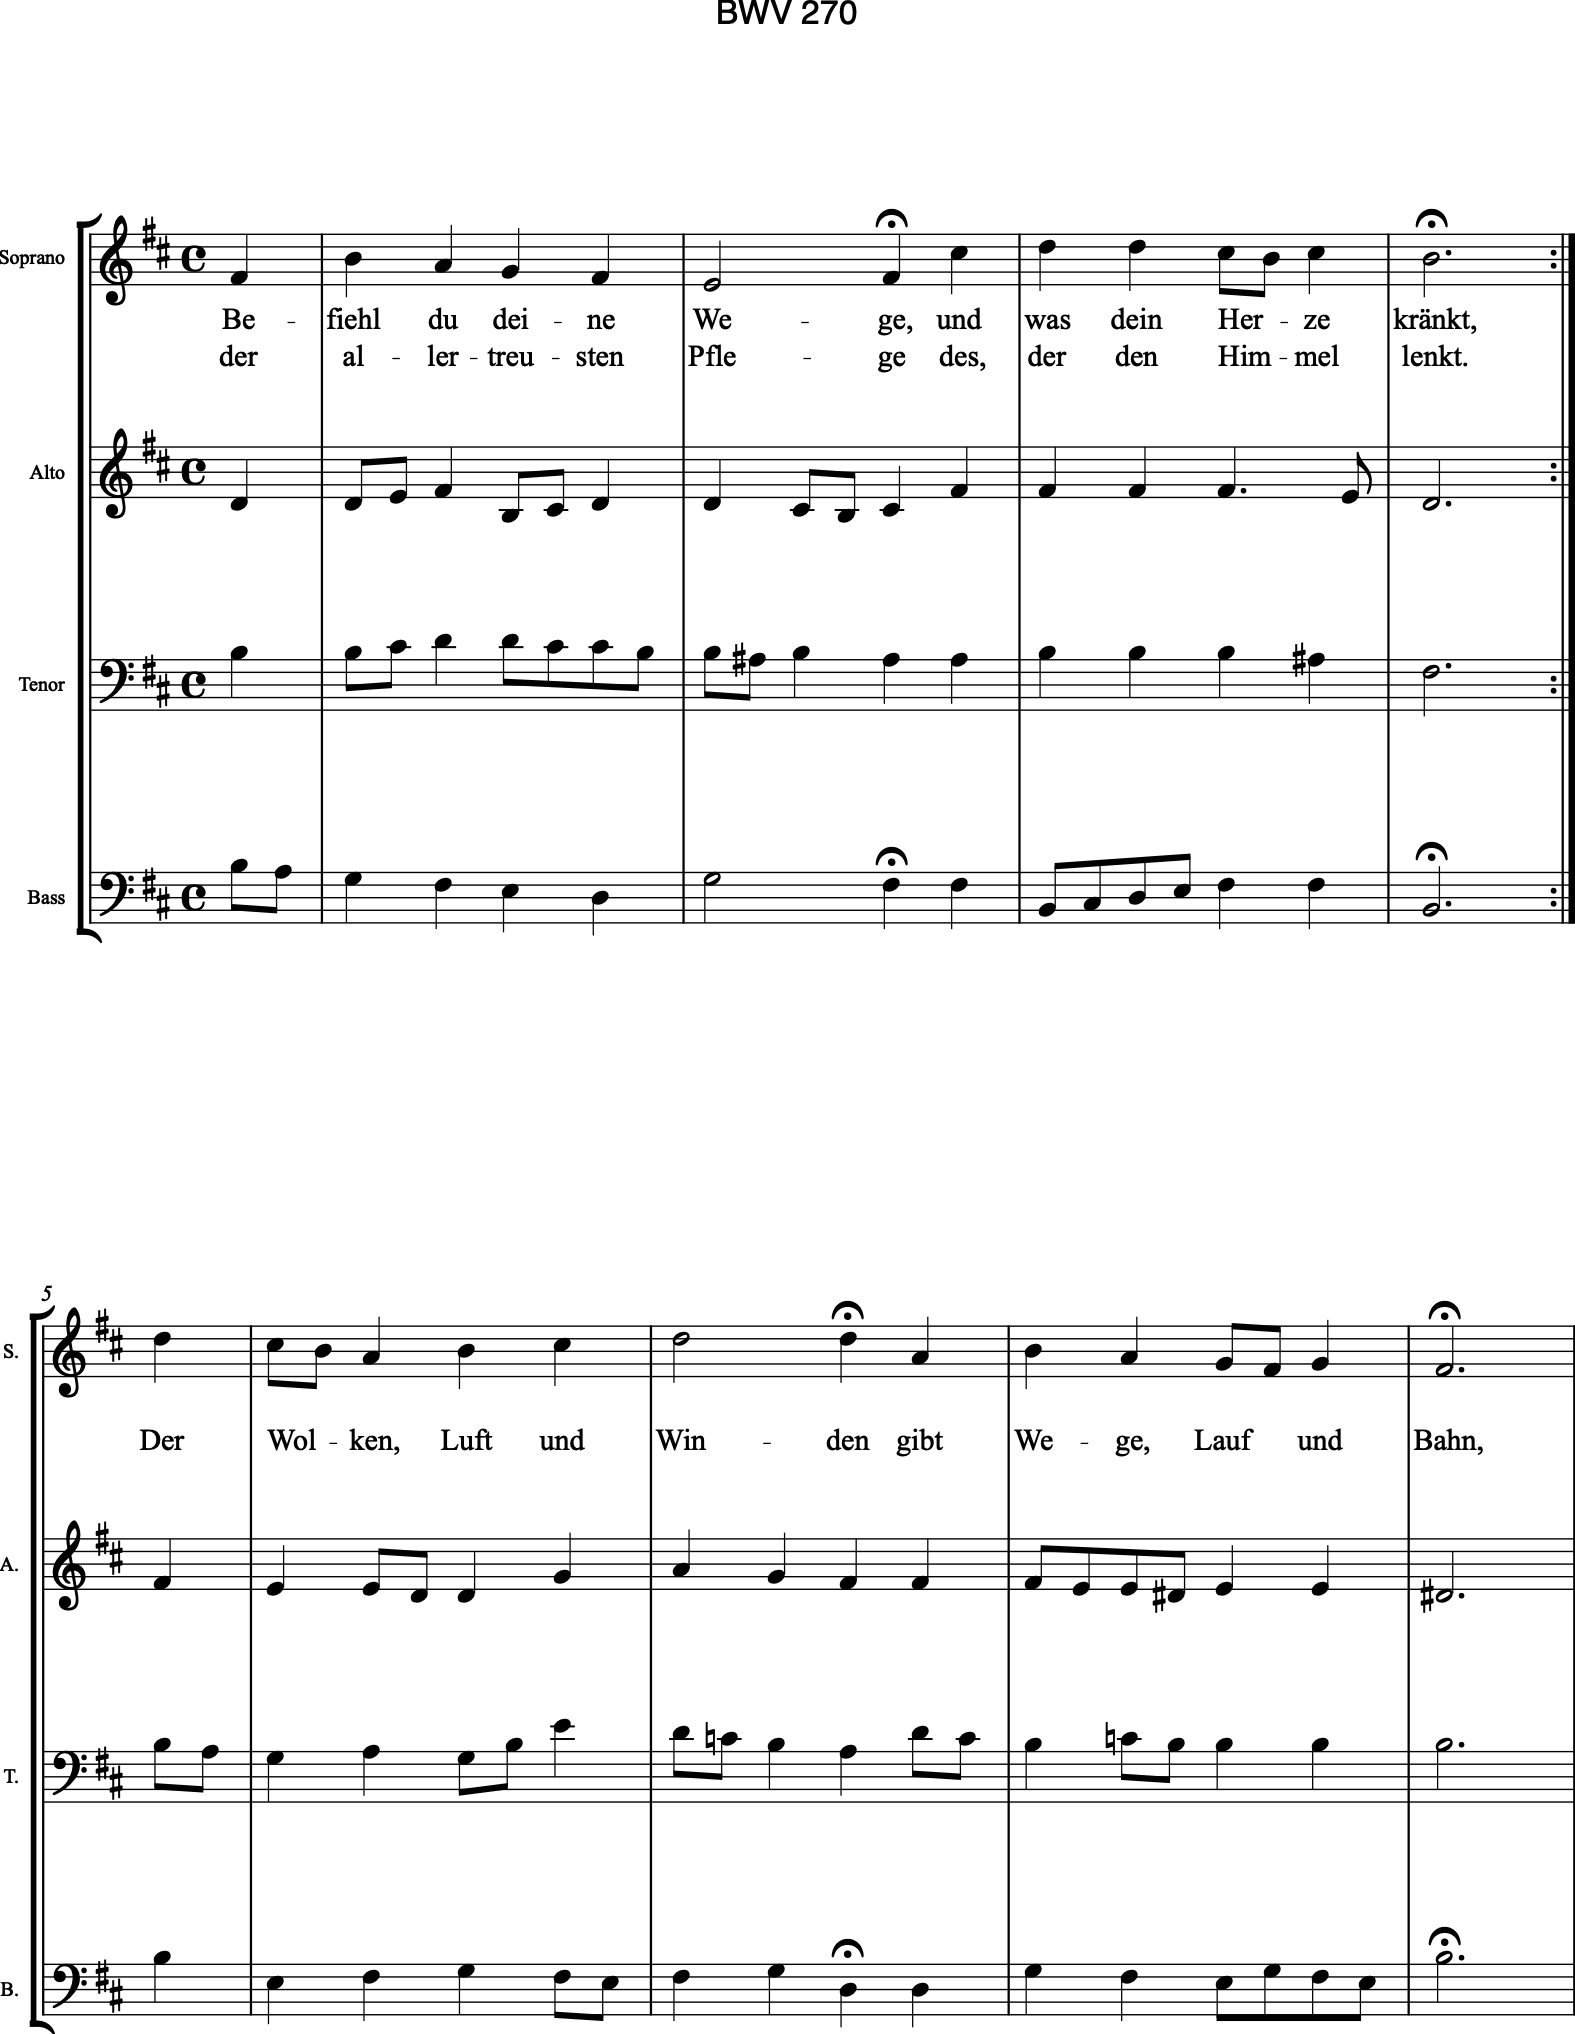

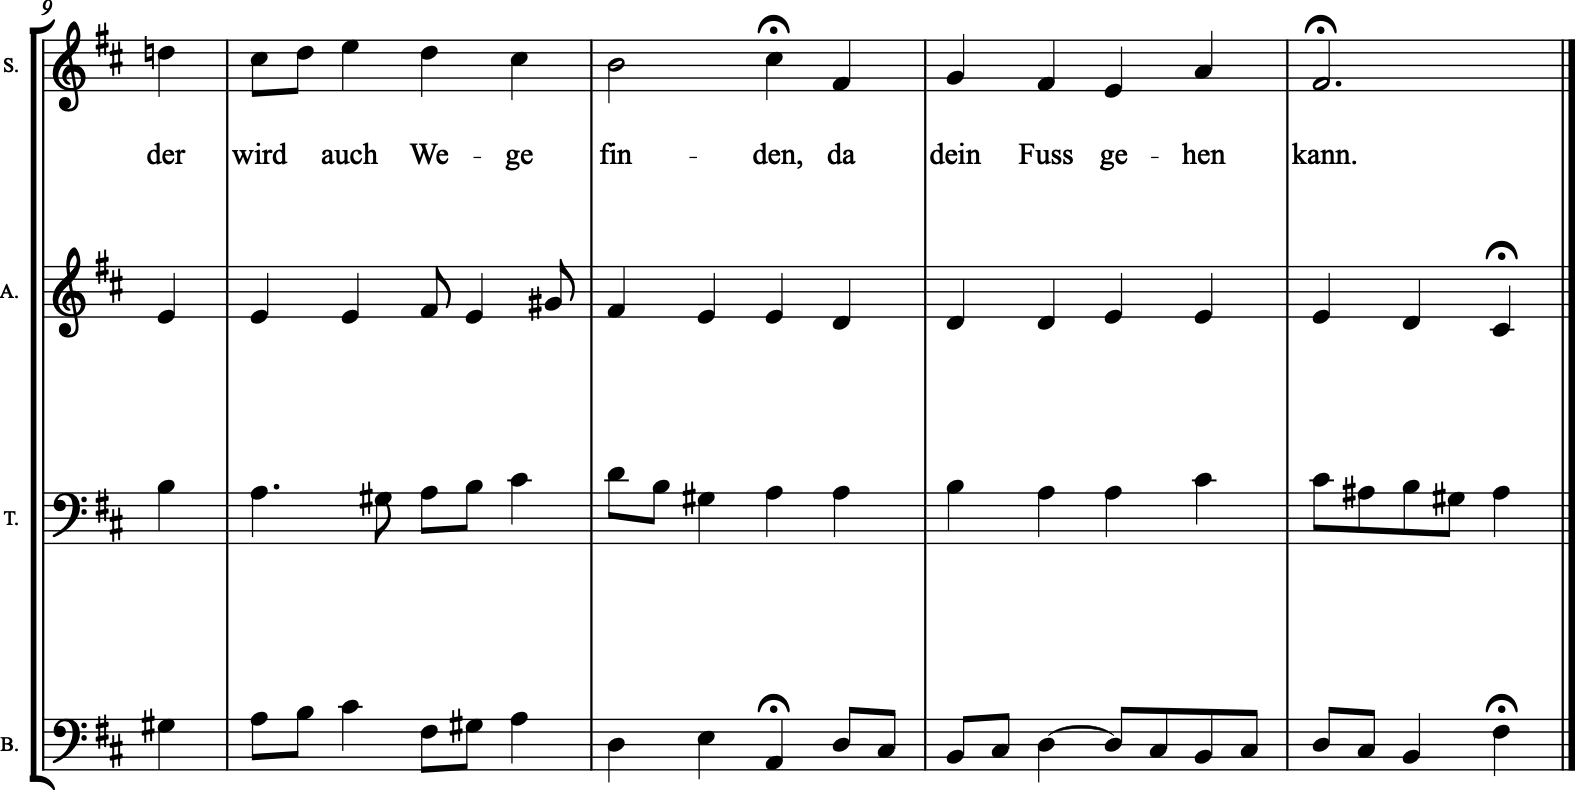

In [8]:
score = m21.corpus.parse("bach/bwv270.mxl")

score.show()


# TESTS

In [ ]:
import music21 as m21
piece = corpus.parse("schoenberg/opus19", 6)
piece.id = "Original"

pieceChords = piece.chordify()
pieceChords.id = "Chords"

for chord in pieceChords.recurse().getElementsByClass(m21.chord.Chord):
    chord.closedPosition(forceOctave=4, inPlace=True)

piece.insert(0, pieceChords)
piece.show()
# Why does an error occur when calling it as musicxml

0 1 Bass-Tenor
0 2 Bass-Alto
0 3 Bass-Soprano
1 2 Tenor-Alto
1 3 Tenor-Soprano
2 3 Alto-Soprano


The Key Signature is: e minor


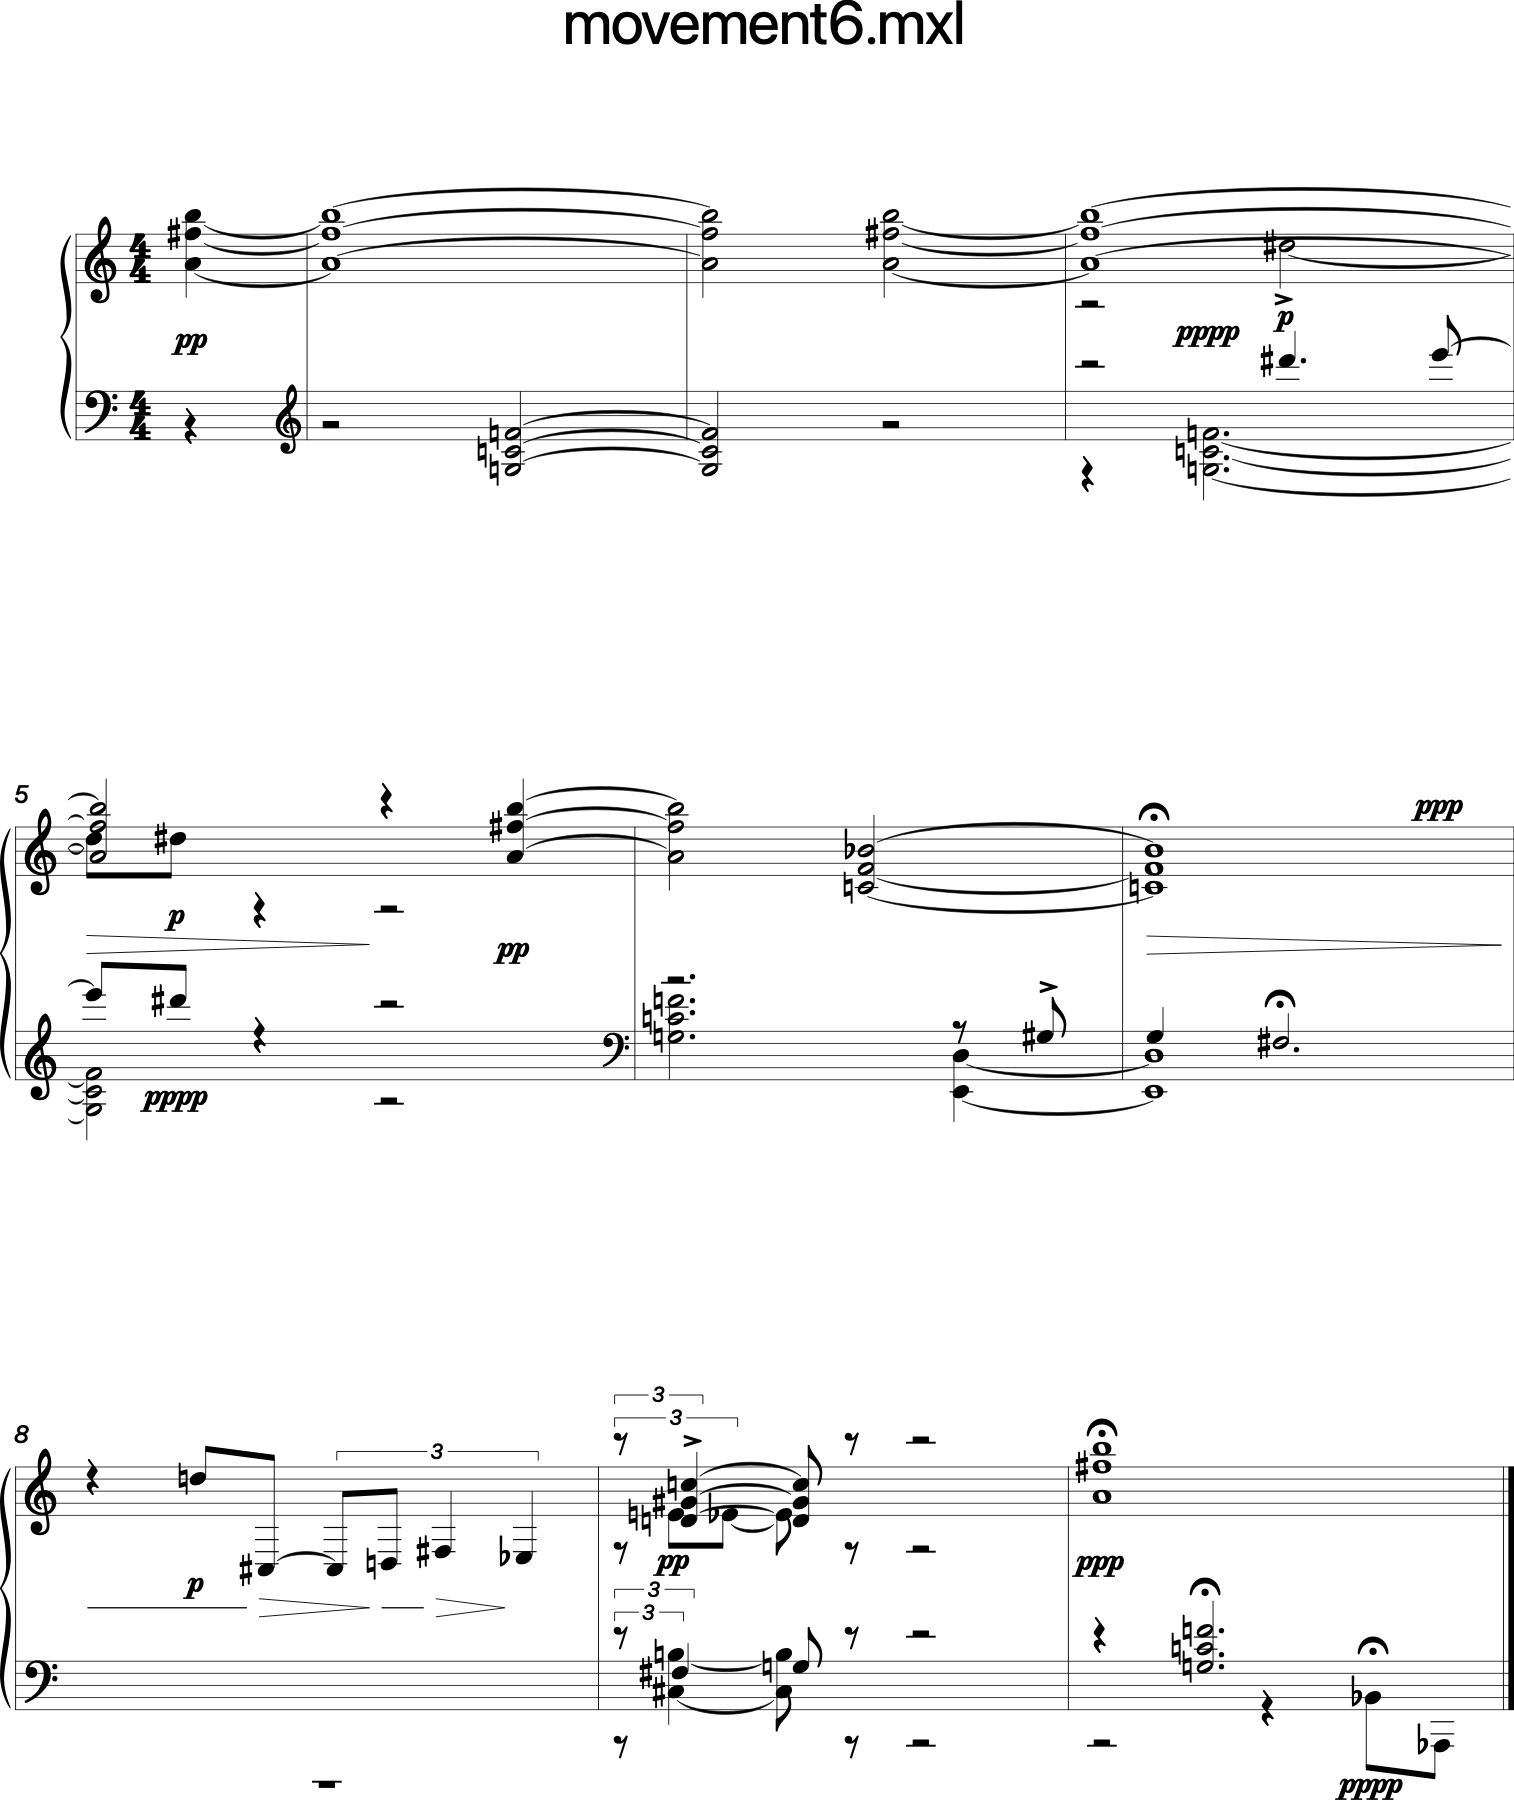

In [16]:
piece = corpus.parse("schoenberg/opus19", 6)
piece_key = piece.analyze("key")
print(f"The Key Signature is: {piece_key}")
piece.show()

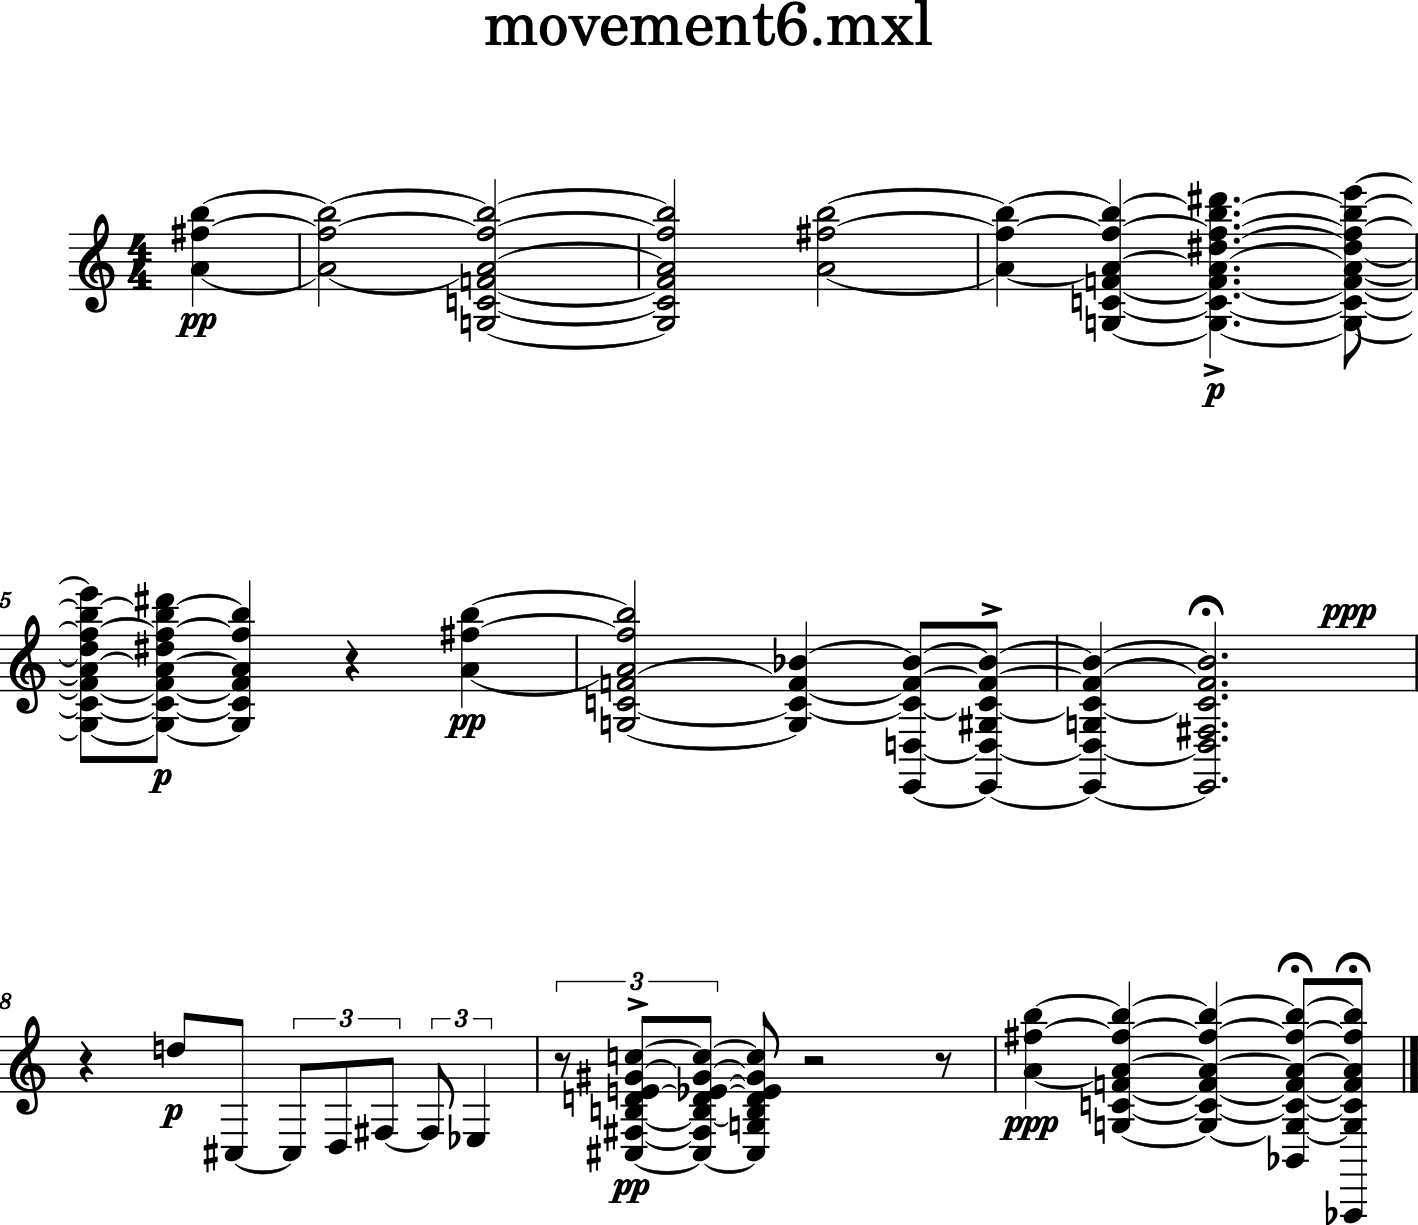

In [27]:
pieceChords = piece.chordify()
pieceChords.show()

In [54]:
pieceChords = piece.chordify()
for chords in pieceChords.recurse().getElementsByClass(m21.chord.Chord):
    if chords.beatStrength == 1:
        print(chords, chords.measureNumber)

<music21.chord.Chord A4 F#5 B5> 2
<music21.chord.Chord G3 C4 F4 A4 F#5 B5> 3
<music21.chord.Chord A4 F#5 B5> 4
<music21.chord.Chord G3 C4 F4 A4 D#5 F#5 B5 E6> 5
<music21.chord.Chord G3 C4 F4 A4 F#5 B5> 6
<music21.chord.Chord E2 D3 G3 C4 F4 B-4> 7
<music21.chord.Chord A4 F#5 B5> 10


In [52]:
m1 = m21.stream.Measure(number=1)
bass_clef = m21.clef.BassClef()

g = m21.note.Note("G3")
e_flat = m21.note.Note("Eb3")
stream1 = m21.stream.Stream()

m1.repeatAppend(g, 3)
m1.append(e_flat)
stream1.append(m1)
stream1.append(bass_clef)
stream1.show("midi")

In [45]:
import music21 as m21
g = m21.note.Note("G9")

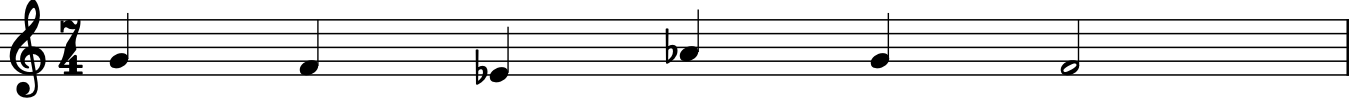

In [113]:
m1 = m21.stream.Measure(number=1)
treble = m21.clef.TrebleClef()

g = m21.note.Note("G4")
f = m21.note.Note("F4")
e_flat = m21.note.Note("E-4")
a_flat = m21.note.Note("A-4")
g_1 = m21.note.Note("G4")
f_1 = m21.note.Note("F4")
f_1.duration.quarterLength = 2
m1.append([g, f, e_flat, a_flat, g_1, f_1])
m1.show()

# elegant way